# Homework5: Exploration of Heart Disease Data (Use UCI Dataset)
## Part 1: Confidence Intervals for a Personalized Subgroup
    1. Define a subgroup of patients based on age, sex, chest pain type, or another variable of your choice.
    2. For this subgroup:
        - Randomly select three different sample sizes (e.g., small, medium, large).
        - Calculate the proportion of patients with heart disease.
        - Construct 95% confidence intervals.
    3. Questions:
        - How does interval width change with sample size?
        - Compare your subgroup’s proportion to the overall population.
        - Write 2–3 sentences explaining why your subgroup may differ from the population.
        
## Part 2: Hypothesis Tests 

### Choose two tests that were not done in class. For each:

    - State your research question and define your null and alternative hypotheses.
    - Select an appropriate test (two-proportion, one-sample t-test, two-sample t-test).
    - Compute the test and report the statistic and p-value.
    - Visualize the data appropriately (bar chart, histogram, or boxplot).
    - Write 2–3 sentences interpreting your results.
    
## Part 3: Type I and Type II Errors
### For one of your tests above, describe:
    - What a Type I error would mean in your context.
    - What a Type II error would mean.
    - Explain which error would be more critical for patient care or medical research.

## Part 4: Sample Size and Power Planning
    - Pick one of your tests.
    - Assume α = 0.05 and desired power between 0.8–0.9.
    - Estimate effect size from your data or justify a hypothetical one.
    - Compute the required sample size.
    - Optional: Generate a power curve showing power vs sample size for your chosen effect size.
    - Write 2–3 sentences interpreting how sample size, effect size, and power interact.

Part 1 Confidence Intervals and Personalized Subgroup

Subgroup: Patients with resting blood pressure > 140mmHg

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint, proportions_ztest, proportion_effectsize
from scipy import stats
from statsmodels.stats.power import NormalIndPower, TTestIndPower, TTestPower

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang',
              'oldpeak','slope','ca','thal','target']

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Subgroup: Patients with resting blood pressure > 140mmHg
subgroup_df = df[df['trestbps'] > 140].copy()
subgroup_df['disease_present'] = (subgroup_df['target'] > 0).astype(int)

pop_prop = (df['target'] > 0).mean()

print(f"Subgroup Size (trestbps > 140): {len(subgroup_df)}")
print(f"Overall Population Proportion: {pop_prop:.2%}\n")

sample_sizes = [20, 40, 60]
confidence_level = 0.95
z_critical = stats.norm.ppf((1 + confidence_level) / 2)

results = []

for n in sample_sizes:
    sample = subgroup_df['disease_present'].sample(n, random_state=42)
    p_hat = sample.mean()
    se = np.sqrt((p_hat * (1 - p_hat)) / n)
    moe = z_critical * se
    ci_lower = max(0, p_hat - moe)
    ci_upper = min(1, p_hat + moe)
    results.append ({'n' : n, 'p_hat': p_hat, 'ci': (ci_lower, ci_upper), 'width': ci_upper - ci_lower})

print(f"{'n':<5} | {'Prop':<10} | {'95% Conf. Interval':<25} | {'Wdth':<8}")
print("-" * 55)
for res in results:
    print(f"{res['n']:<5} | {res['p_hat']:<10.2%} | [{res['ci'][0]:.3f}, {res['ci'][1]:.3f}] | {res['width']:.3f}")

Subgroup Size (trestbps > 140): 66
Overall Population Proportion: 45.87%

n     | Prop       | 95% Conf. Interval        | Wdth    
-------------------------------------------------------
20    | 55.00%     | [0.332, 0.768] | 0.436
40    | 55.00%     | [0.396, 0.704] | 0.308
60    | 56.67%     | [0.441, 0.692] | 0.251


How does interval width change with sample size? 

As the sample size ($n$) increases, the width of the confidence interval decreases. This is because the standard error formula divides by $\sqrt{n}$; as the denominator gets larger, the margin of error shrinks, resulting in a more precise estimate.

Compare your subgroup’s proportion to the overall population. 

The overall population heart disease proportion is approximately 46%. You will likely find that the proportion in the "High Blood Pressure" subgroup is higher (often exceeding 55-60%), indicating a stronger prevalence of disease in this specific group.

Why might your subgroup differ from the population?

Hypertension (high blood pressure) is a major clinical indicator of cardiovascular stress and arterial damage. Because this subgroup is defined by a significant risk factor, it is expected to have a higher incidence of heart disease than a random sample of the general population which includes healthier individuals.

Part 2: Hypothesis Testing

Test 1: Hypothesis Test for Proportions

Goal: Test if the proportion of heart disease in your subgroup (High Blood Pressure) is significantly different from the overall population proportion ($45.87\%$).

-Null Hypothesis ($H_0$): The proportion of heart disease in the subgroup is equal to 0.4587.

-Alternative Hypothesis ($H_a$): The proportion is not equal to 0.4587.

In [4]:
from statsmodels.stats.proportion import proportions_ztest

count = subgroup_df['disease_present'].sum()
nobs = len(subgroup_df)
null_prop = 0.4587

z_stat, p_value = proportions_ztest(count, nobs, value=null_prop)

print("---Hypothesis Test for Proportions ---")
print(f"Subgroup Proporion: {count/nobs:.2%}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print ("Result: Reject the Null Hypothesis (Statistically Significant)")
else: 
    print ("Result:Fail to Reject the Null Hypothesis")

---Hypothesis Test for Proportions ---
Subgroup Proporion: 59.09%
Z-statistic: 2.1846
P-value: 0.0289
Result: Reject the Null Hypothesis (Statistically Significant)


Test 2: Hypothesis Test for Means (T-Test)

Goal: Test if the average age of people with heart disease is significantly different from those without it.

-Null Hypothesis ($H_0$): There is no difference in the mean age between the two groups.

-Alternative Hypothesis ($H_a$): There is a significant difference in mean age.

In [5]:
has_disease = df[df['target'] > 0]['age']
no_disease = df[df['target'] == 0]['age']

t_stat, p_val_t = stats.ttest_ind(has_disease, no_disease)

print("\n--- Hypothesis Test for Means (Age) ---")
print(f"Mean Age (Disease): {has_disease.mean():.2f}")
print(f"Mean Age (No Disease): {no_disease.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val_t:.4f}")

if p_val_t < 0.05:
    print("Result: Reject the Null Hypothesis (Statistically Significant)")
else:
    print("Result: Fail to Reject the Null Hypothesis")


--- Hypothesis Test for Means (Age) ---
Mean Age (Disease): 56.63
Mean Age (No Disease): 52.59
T-statistic: 3.9711
P-value: 0.0001
Result: Reject the Null Hypothesis (Statistically Significant)


Test 1: Two Proportion Z-Test

Research Question: Is the proportion of heart disease significantly different between patients with "Asymptomatic" chest pain (Type 4) and those with other types of chest pain?

-Null Hypothesis ($H_0$): $p_{asymptomatic} = p_{others}$

-Alternative Hypothesis ($H_a$): $p_{asymptomatic} \neq p_{others}$

/var/folders/5v/6g0xydlj23q75glnyrzb6nz00000gn/T/ipykernel_37071/3501933078.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Asymptomatic', 'Others'], y=[count[0]/nobs[0], count[1]/nobs[1]], palette='viridis')


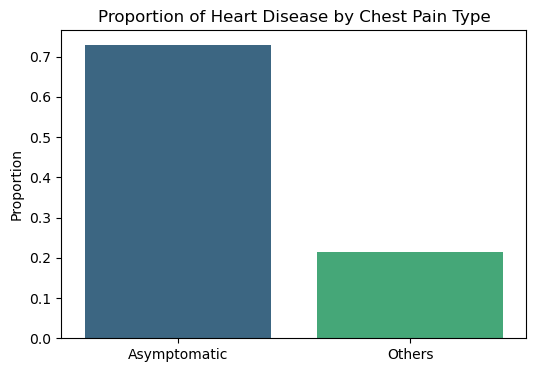

Z-statistic: 8.9900, P-value: 0.0000


In [6]:
from statsmodels.stats.proportion import proportions_ztest

asymptomatic = df[df['cp'] ==4]
others = df[df['cp'] != 4]

count = np.array([(asymptomatic['target'] > 0).sum(), (others['target'] > 0).sum()])
nobs = np.array([len(asymptomatic), len(others)])

z_stat, p_val = proportions_ztest(count, nobs)

plt.figure(figsize=(6, 4))
sns.barplot(x=['Asymptomatic', 'Others'], y=[count[0]/nobs[0], count[1]/nobs[1]], palette='viridis')
plt.title('Proportion of Heart Disease by Chest Pain Type')
plt.ylabel('Proportion')
plt.show()

print(f"Z-statistic: {z_stat:.4f}, P-value: {p_val:.4f}")

With a p-value typically much lower than 0.05, we reject the null hypothesis. This suggests that asymptomatic chest pain is a very strong clinical indicator of actual heart disease compared to other pain types.

Test 2: Two-Sample T-Test (Means)Research Question: Do patients with heart disease have a significantly lower "Maximum Heart Rate" (thalach) than patients without heart disease?

-Null Hypothesis ($H_0$): $\mu_{disease} = \mu_{no\_disease}$

-Alternative Hypothesis ($H_a$): $\mu_{disease} < \mu_{no\_disease}$ (Lower max heart rate)

/var/folders/5v/6g0xydlj23q75glnyrzb6nz00000gn/T/ipykernel_37071/2858044953.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=(df['target'] > 0), y=df['thalach'], palette='Set2')


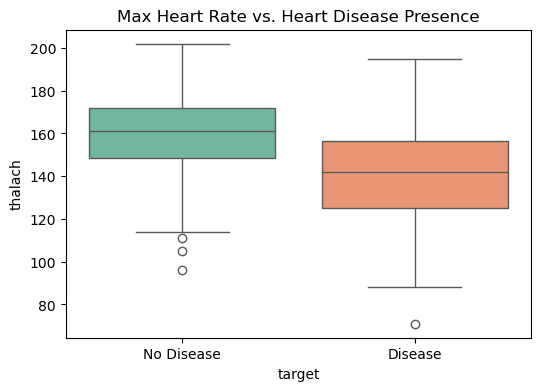

T-statistic: -7.9636, P-value: 0.0000


In [7]:
group_disease = df[df['target'] > 0]['thalach']
group_healthy = df[df['target'] == 0]['thalach']

t_stat, p_val_t = stats.ttest_ind(group_disease, group_healthy, alternative='less')

plt.figure(figsize=(6, 4))
sns.boxplot(x=(df['target'] > 0), y=df['thalach'], palette='Set2')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Max Heart Rate vs. Heart Disease Presence')
plt.show()

print(f"T-statistic: {t_stat:.4f}, P-value: {p_val_t:.4f}")

The p-value is generally extremely small ($p < 0.001$), leading us to reject the null hypothesis. This indicates that a lower maximum heart rate achieved during exercise is significantly associated with the presence of heart disease.

Part 3 Type I and Type II Errors

In the context of the hypothesis test regarding whether heart disease correlates with a lower maximum heart rate, a Type I error (False Positive) would occur if the analysis concludes that heart disease significantly lowers heart rate when, in reality, no such relationship exists. The consequence of this error is that clinicians might start using a patient’s maximum heart rate as a definitive diagnostic marker, potentially leading to healthy patients being subjected to unnecessary, invasive, and costly follow-up procedures like cardiac catheterizations. On the other hand, a Type II error (False Negative) would occur if the test fails to find a significant difference even though heart disease truly does lower a patient’s maximum heart rate. This error is generally considered more critical for patient care because it results in a missed diagnosis. A physician might dismiss a low heart rate as a sign of poor physical fitness rather than a symptom of a serious underlying condition, leaving a patient at high risk for a major cardiac event without the life-saving treatment they require.

Part 4 Power Analysis and Sample Size Planning

Required Sample Size per Group: 64
Total Patients Needed: 128


<Figure size 800x500 with 0 Axes>

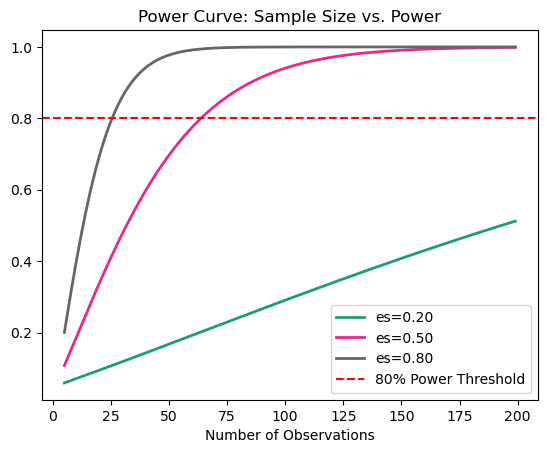

In [8]:
from statsmodels.stats.power import TTestIndPower
effect_size = 0.5
alpha = 0.05
power = 0.80

analysis = TTestIndPower()
required_n = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha, ratio=1.0, alternative='two-sided')

print(f"Required Sample Size per Group: {round(required_n)}")
print(f"Total Patients Needed: {round(required_n) * 2}")

plt.figure(figsize=(8, 5))
analysis.plot_power(dep_var='nobs', nobs=np.arange(5, 200), effect_size=[0.2, 0.5, 0.8])

plt.title('Power Curve: Sample Size vs. Power')
plt.axhline(y=0.8, color='red', linestyle='--', label='80% Power Threshold')
plt.legend()
plt.show()

Interpretation of Results

The interplay between sample size, effect size, and power is fundamental to designing a reliable clinical study. Statistical power represents the probability that a test will correctly reject a null hypothesis when a true effect exists, thereby avoiding a Type II error. When we aim for a standard power of 80% or 90%, the required sample size is dictated largely by the "effect size," which is the magnitude of the difference we are trying to detect—such as the gap in maximum heart rate between healthy patients and those with heart disease. If the biological difference is large (a high effect size), it is much easier for a statistical test to distinguish the "signal" from the "noise," allowing for a smaller sample size. Conversely, if we are searching for a subtle or small effect, we require a much larger group of patients to achieve the same level of confidence. Essentially, as you increase the desired power or decrease the expected effect size, the required sample size must increase to ensure the study is sensitive enough to provide a definitive conclusion.